In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px

In [18]:
# Lendo o arquivo CSV do supermercado chileno
# Usamos delimiter=';' porque as colunas dessa base são separadas por ponto e vírgula.
df = pd.read_csv("/content/drive/MyDrive/Projetos em Ciência de Dados/Projeto_3 - EBAC/MODULO7_PROJETOFINAL_BASE_SUPERMERCADO - MODULO7_PROJETOFINAL_BASE_SUPERMERCADO (1).csv (1).csv")
# Mostrando as 10 primeiras linhas para conferir se carregou certinho
df.head(10)

,title,Marca,Preco_Normal,Preco_Desconto,Preco_Anterior,Desconto,Categoria
0,"Pack 12 un, Leche extra proteína 1 L",Loncoleche,19788,0,0,0,lacteos
1,"Pack 12 un, Leche chocolate receta original 1 L",Soprole,18228,0,0,0,lacteos
2,"Pack 12 un, Leche semidescremada chocolate 1 L",Soprole,18228,0,0,0,lacteos
3,"Pack 12 un, Leche semidescremada frutilla 1 L",Soprole,18228,0,0,0,lacteos
4,"Pack 12 un, Leche sin lactosa chocolate 1 L",Loncoleche,17988,0,0,0,lacteos
5,"Pack 12 un, Leche sin lactosa frutilla 1 L",Loncoleche,17988,0,0,0,lacteos
6,"Pack 12 un, Leche saborizada light chocolate 1 L",Loncoleche,17988,0,0,0,lacteos
7,"Pack 12 un, Leche saborizada frutilla 1 L",Colun,17388,0,0,0,lacteos
8,"Pack 12 un, Leche saborizada vainilla 1 L",Colun,17388,0,0,0,lacteos
9,"Pack 12 un, Leche saborizada manjar 1 L",Colun,17388,0,0,0,lacteos


In [19]:
# Calculando a média e a mediana do Preco_Normal por Categoria
media_preco = df.groupby('Categoria')['Preco_Normal'].mean()
mediana_preco = df.groupby('Categoria')['Preco_Normal'].median()
# Juntando as duas em uma tabela organizada para comparar facilmente
resumo_estatistico = pd.DataFrame({
'Média': media_preco,
'Mediana': mediana_preco
})
display(resumo_estatistico)

,Média,Mediana
Categoria,,
belleza-y-cuidado-personal,1783.556485,1569.0
comidas-preparadas,3095.043478,3290.0
congelados,2108.042553,1519.0
frutas,1724.473684,1195.0
instantaneos-y-sopas,765.491228,439.0
lacteos,2385.219239,989.0
verduras,1343.296875,1180.0


In [20]:
# Calculando o desvio padrão do Preco_Normal por Categoria
desvio_padrao_preco = df.groupby('Categoria')['Preco_Normal'].std().sort_values(ascending=False)
print(desvio_padrao_preco)

Categoria
lacteos                       3925.816164
belleza-y-cuidado-personal    2210.041719
congelados                    2111.539896
comidas-preparadas            2019.911428
frutas                        1639.151114
instantaneos-y-sopas          1170.232869
verduras                      1012.699625
Name: Preco_Normal, dtype: float64


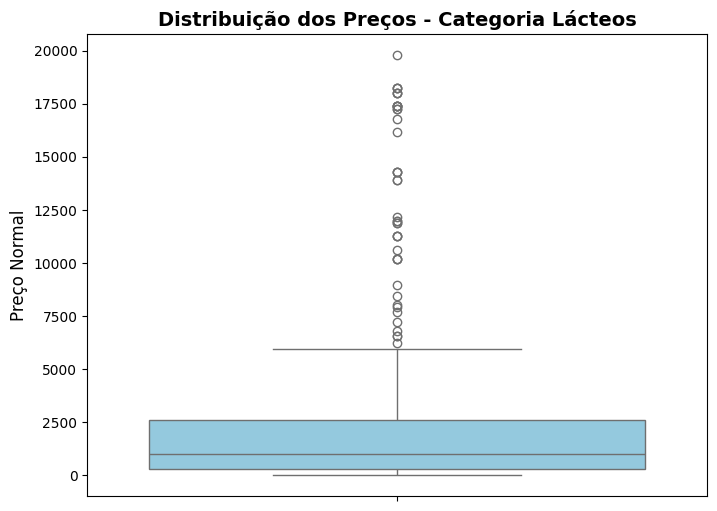

In [32]:
import seaborn as sns
# Filtrando apenas os dados da categoria com maior desvio padrão (lacteos)
df_lacteos = df[df['Categoria']=='lacteos']
# Configurando o tamanho do gráfico
plt.figure(figsize=(8,6))
# Criando o boxplot
sns.boxplot(y=df_lacteos['Preco_Normal'], color='skyblue')
# Adicionando títulos e rótulos profissionais
plt.title('Distribuição dos Preços - Categoria Lácteos', fontsize=14, fontweight='bold')
plt.ylabel('Preço Normal', fontsize=12)
#Salvando a imagem
plt.savefig('boxplot_lacteos.png', dpi=300, bbox_inches='tight')
plt.show()

In [22]:
# Filtrando apenas a categoria de laticínios
df_lacteos = df[df['Categoria']=='lacteos']
# Calculando Q1 (25%), Q3 (75%) e o IQR
Q1 = df_lacteos['Preco_Normal'].quantile(0.25)
Q3 = df_lacteos['Preco_Normal'].quantile(0.75)
IQR = Q3 - Q1
# Definindo o limite superior para identificar outliers
limite_superior = Q3 + 1.5 * IQR
# Filtrando os produtos que estão acima desse limite (nossos outliers)
outliers_lacteos = df_lacteos[df_lacteos['Preco_Normal']>limite_superior]
print(f"Total de outliers encontrados em Lácteos:{len(outliers_lacteos)}")
display(outliers_lacteos[['title', 'Marca','Preco_Normal']].head(10))

Total de outliers encontrados em Lácteos:43


,title,Marca,Preco_Normal
0,"Pack 12 un, Leche extra proteína 1 L",Loncoleche,19788
1,"Pack 12 un, Leche chocolate receta original 1 L",Soprole,18228
2,"Pack 12 un, Leche semidescremada chocolate 1 L",Soprole,18228
3,"Pack 12 un, Leche semidescremada frutilla 1 L",Soprole,18228
4,"Pack 12 un, Leche sin lactosa chocolate 1 L",Loncoleche,17988
5,"Pack 12 un, Leche sin lactosa frutilla 1 L",Loncoleche,17988
6,"Pack 12 un, Leche saborizada light chocolate 1 L",Loncoleche,17988
7,"Pack 12 un, Leche saborizada frutilla 1 L",Colun,17388
8,"Pack 12 un, Leche saborizada vainilla 1 L",Colun,17388
9,"Pack 12 un, Leche saborizada manjar 1 L",Colun,17388


Categoria
congelados                    154.029787
belleza-y-cuidado-personal    123.083682
comidas-preparadas             43.478261
lacteos                        17.411633
frutas                          0.000000
instantaneos-y-sopas            0.000000
verduras                        0.000000
Name: Desconto, dtype: float64


/tmp/ipykernel_2020/3144098899.py:7: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




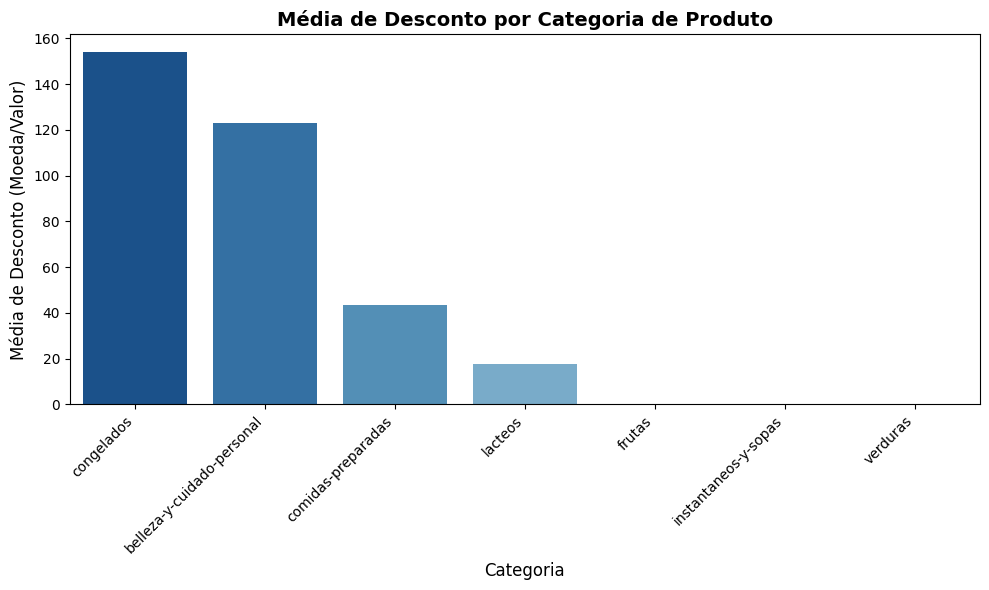

In [33]:
# Calculando a média de desconto por categoria
media_desconto = df.groupby('Categoria')['Desconto'].mean().sort_values(ascending=False)
print(media_desconto)
# Configurando o tamanho do gráfico
plt.figure(figsize=(10,6))
# Criando o gráfico de barras
ax = sns.barplot(x=media_desconto.index, y=media_desconto.values,  palette='Blues_r')
# Adicionando títulos e rótulos profissionais
plt.title('Média de Desconto por Categoria de Produto', fontsize=14, fontweight='bold')
plt.xlabel('Categoria', fontsize=12)
plt.ylabel('Média de Desconto (Moeda/Valor)', fontsize=12)
# Rotacionando os nomes das categorias no eixo X para facilitar a leitura
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
#Salvando a imagem
plt.savefig('grafico_barras_desconto.png', dpi=300, bbox_inches='tight')
plt.show()

In [25]:
# Agrupando os dados por Categoria e Marca para calcular a média de desconto
df_agrupado = df.groupby(['Categoria', 'Marca'])['Desconto'].mean().reset_index()
# Filtrando apenas os registros que possuem desconto maior que zero
# (evita o erro de divisão por zero no Treemap)
df_agrupado = df_agrupado[df_agrupado['Desconto']>0]
# Criando um gráfico de árvore interativo (Treemap)
fig = px.treemap(
    df_agrupado,
    path=['Categoria', 'Marca'],
    values='Desconto',
    title='Mapa Interativo: Média de Desconto por Categoria e Marca',
    color='Desconto',
    color_continuous_scale='Blues',
)
fig.show()

In [31]:
#Salvando as imagens
plt.savefig('boxplot_lacteos.png', dpi=300, bbox_inches='tight')
plt.show()

<Figure size 640x480 with 0 Axes>

In [29]:
plt.savefig('grafico_barras_desconto.png', dpi=300, bbox_inches='tight')

<Figure size 640x480 with 0 Axes>